In [86]:
pip install pandas numpy scipy openpyxl xlrd matplotlib lxml html5lib beautifulsoup4

   ---------------------------------------- 0.0/106.4 kB ? eta -:--:--
   --- ------------------------------------ 10.2/106.4 kB ? eta -:--:--
   --------------- ----------------------- 41.0/106.4 kB 653.6 kB/s eta 0:00:01
   ---------------------------------------- 106.4/106.4 kB 1.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: C:\Users\HP'\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [87]:
# Read → 1s Downsample → HRV
# ===========================
import numpy as np, pandas as pd
from pathlib import Path
from scipy.signal import find_peaks, welch
from scipy.interpolate import interp1d

In [ ]:
INPUT_FILE = Path("./Stress induction/0.xlsx")
OUT_DIR    = Path("./data/analysis_results/conventional meditation/0"); OUT_DIR.mkdir(parents=True, exist_ok=True)


In [336]:
# Column mapping typical for Biofeedback 2000 Xpert
COLMAP = {
    "Zeit":"time", "U_13_SCL":"SCL", "U_14_SCR":"SCR", "U_15_Tem":"TEMP",
    "U_16_BVP":"BVP", "U_17_PVA":"PVA", "U_18_Puls":"HR", "U_19_Mot":"MOTION",
    "Bemerkung":"NOTE"
}

def parse_time_to_seconds(s):
    """Convert 'HH:MM:SS(.fff)' (dot or comma decimals) to seconds float."""
    if pd.isna(s): return np.nan
    s = str(s).strip()
    try:
        hh, mm, rest = s.split(":")
        rest = rest.replace(",", ".")
        return int(hh)*3600 + int(mm)*60 + float(rest)
    except Exception:
        return np.nan

def read_excel_any(path: Path) -> pd.DataFrame:
    """Robust loader for mixed .xls/.xlsx/.xls.xlsx and HTML-exported .xls."""
    try:
        return pd.read_excel(path, engine="openpyxl")
    except Exception:
        try:
            return pd.read_excel(path)  # pandas auto
        except Exception:
            # try HTML disguised as .xls
            try:
                tables = pd.read_html(path)
                tables.sort(key=lambda t: t.shape[1], reverse=True)
                return tables[0]
            except Exception as e:
                raise


In [337]:
# ---- 1) Load & normalize columns ----
df = read_excel_any(INPUT_FILE)
df.columns = [str(c).strip() for c in df.columns]
for k, v in COLMAP.items():
    if k in df.columns: df.rename(columns={k: v}, inplace=True)

if "time" not in df.columns:
    raise RuntimeError(f"No 'Zeit'/'time' column found. Columns = {df.columns.tolist()}")

# ---- 2) Parse time to seconds, sort ----
df["sec"] = df["time"].apply(parse_time_to_seconds)
df = df[df["sec"].notna()].sort_values("sec").reset_index(drop=True)

# Convert decimal commas and coerce to numeric for known signals
signals = [c for c in ["SCL","SCR","TEMP","BVP","PVA","HR","MOTION"] if c in df.columns]
for c in signals:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")


C:\Users\HP'\AppData\Local\Temp\ipykernel_22468\2011092594.py:29: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(path)


ValueError: No tables found

In [322]:
# ---- 3) Downsample to 1-second bins (mean within each second) ----
df["sec_bin"] = np.floor(df["sec"]).astype(int)
down_1s = df.groupby("sec_bin")[signals].mean().rename_axis("sec").reset_index()

# ---- 4) HRV (preferred: BVP; fallback: HR) ----
def hrv_from_bvp(t, x):
    """BVP → RR → HRV with aligned masks (prevents length mismatch)."""
    m = np.isfinite(t) & np.isfinite(x)
    t = np.asarray(t)[m]; x = np.asarray(x)[m]
    if t.size < 10: return {"ok":False, "reason":"too few samples"}

    dt = np.median(np.diff(t)); dt = 0.01 if not np.isfinite(dt) or dt<=0 else dt
    x_d = x - np.nanmean(x)
    min_dist = max(1, int(0.30 / max(dt, 1e-6)))      # ≥0.30 s between peaks (~≤200 bpm)
    prom = 0.3*np.nanstd(x_d) if np.isfinite(np.nanstd(x_d)) else None
    peaks, _ = find_peaks(x_d, distance=min_dist, prominence=prom)
    if peaks.size < 3: return {"ok":False, "reason":"no peaks"}

    t_peaks = t[peaks]
    rr_all = np.diff(t_peaks)                          # seconds
    ok = (rr_all >= 0.30) & (rr_all <= 2.00)           # physiologic range
    rr   = rr_all[ok]
    t_rr = t_peaks[1:][ok]                             # ALIGN mask with rr (important)
    if rr.size < 3: return {"ok":False, "reason":"few valid RR"}

    # Time-domain HRV
    mean_hr = float(60.0/np.mean(rr))
    sdnn    = float(np.std(rr, ddof=1))               # SDNN (s)
    drr     = np.diff(rr)
    rmssd   = float(np.sqrt(np.mean(drr**2))) if drr.size>0 else np.nan  # RMSSD (s)
    pnn50   = float(100.0*np.mean(np.abs(drr) > 0.05)) if drr.size>0 else np.nan

    # Frequency-domain HRV via Welch on 4 Hz interpolated tachogram
    lf=hf=lfhf=np.nan
    if t_rr.size >= 4:
        fs = 4.0
        t_uni = np.arange(t_rr.min(), t_rr.max(), 1.0/fs)
        if t_uni.size >= 16:
            f_i  = interp1d(t_rr, rr, kind="linear", bounds_error=False, fill_value="extrapolate")
            rr_i = f_i(t_uni); rr_i = rr_i - np.mean(rr_i)
            f, pxx = welch(rr_i, fs=fs, nperseg=min(256, len(rr_i)))
            LF = (f>=0.04) & (f<0.15); HF = (f>=0.15) & (f<0.40)
            if LF.any(): lf = float(np.trapz(pxx[LF], f[LF]))
            if HF.any(): hf = float(np.trapz(pxx[HF], f[HF]))
            if np.isfinite(lf) and np.isfinite(hf) and hf>0: lfhf = float(lf/hf)

    return {"ok":True, "n_beats": int(t_peaks.size), "mean_HR_bpm": mean_hr,
            "SDNN_s": sdnn, "RMSSD_s": rmssd, "pNN50_percent": pnn50,
            "LF_power": lf, "HF_power": hf, "LF_HF_ratio": lfhf}

def hrv_from_hr_series(sec, hr_bpm):
    """Fallback if BVP missing: estimate RR ≈ 60/HR for time-domain metrics."""
    m = np.isfinite(sec) & np.isfinite(hr_bpm) & (hr_bpm > 0)
    if m.sum() < 8: return {"ok":False, "reason":"insufficient HR samples"}
    rr = 60.0 / np.asarray(hr_bpm)[m]
    if rr.size < 3: return {"ok":False, "reason":"few RR from HR"}
    mean_hr = float(60.0/np.mean(rr))
    sdnn    = float(np.std(rr, ddof=1))
    drr     = np.diff(rr)
    rmssd   = float(np.sqrt(np.mean(drr**2))) if drr.size>0 else np.nan
    pnn50   = float(100.0*np.mean(np.abs(drr) > 0.05)) if drr.size>0 else np.nan
    return {"ok":True,"n_beats":np.nan,"mean_HR_bpm":mean_hr,
            "SDNN_s":sdnn,"RMSSD_s":rmssd,"pNN50_percent":pnn50,
            "LF_power":np.nan,"HF_power":np.nan,"LF_HF_ratio":np.nan}


In [323]:
# Choose HRV source
if "BVP" in df.columns:
    hrv = hrv_from_bvp(df["sec"].to_numpy(), df["BVP"].to_numpy())
elif "HR" in df.columns:
    hrv = hrv_from_hr_series(df["sec"].to_numpy(), df["HR"].to_numpy())
else:
    hrv = {"ok":False, "reason":"no BVP or HR column present"}


C:\Users\HP'\AppData\Local\Temp\ipykernel_22468\496742063.py:43: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  if LF.any(): lf = float(np.trapz(pxx[LF], f[LF]))
C:\Users\HP'\AppData\Local\Temp\ipykernel_22468\496742063.py:44: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  if HF.any(): hf = float(np.trapz(pxx[HF], f[HF]))


In [324]:
# ---- 5) Save outputs ----
down_path  = OUT_DIR / "downsample_1s.csv"
sum_path   = OUT_DIR / "summary_downsample_1s.csv"
hrv_path   = OUT_DIR / "hrv_summary.csv"

down_1s.to_csv(down_path, index=False)

summary = []
for c in signals:
    summary.append({
        "signal": c,
        "mean": float(np.nanmean(down_1s[c])) if c in down_1s else np.nan,
        "std":  float(np.nanstd(down_1s[c]))  if c in down_1s else np.nan,
        "min":  float(np.nanmin(down_1s[c]))  if c in down_1s else np.nan,
        "max":  float(np.nanmax(down_1s[c]))  if c in down_1s else np.nan,
    })
pd.DataFrame(summary).to_csv(sum_path, index=False)
pd.DataFrame([hrv]).to_csv(hrv_path, index=False)

print("Saved:")
print(" - 1s downsample    :", down_path)
print(" - Per-signal summary:", sum_path)
print(" - HRV summary       :", hrv_path)
print("HRV:", hrv)

Saved:
 - 1s downsample    : data\analysis_results\18\downsample_1s.csv
 - Per-signal summary: data\analysis_results\18\summary_downsample_1s.csv
 - HRV summary       : data\analysis_results\18\hrv_summary.csv
HRV: {'ok': True, 'n_beats': 437, 'mean_HR_bpm': 86.68540761564012, 'SDNN_s': 0.12852178677367748, 'RMSSD_s': 0.1598240758602621, 'pNN50_percent': 57.68321513002365, 'LF_power': 0.0020833061550217004, 'HF_power': 0.004050541538129551, 'LF_HF_ratio': 0.5143278091115995}


In [325]:
# Plots + Results (Figures)
# ===========================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks, welch
from scipy.interpolate import interp1d

In [326]:
# INPUT_FILE = Path("./Stress induction/0.xls.xlsx")
# OUT_DIR    = Path("./data/analysis_results")
assert OUT_DIR.exists(), "Run the processing cell first so OUT_DIR exists."

one_sec_csv = OUT_DIR / "downsample_1s.csv"
hrv_csv     = OUT_DIR / "hrv_summary.csv"


In [327]:
# ---------- helpers ----------
def parse_time_to_seconds(s):
    if pd.isna(s): return np.nan
    s = str(s).strip()
    try:
        hh, mm, rest = s.split(":")
        rest = rest.replace(",", ".")
        return int(hh)*3600 + int(mm)*60 + float(rest)
    except: return np.nan

def safe_numeric(a):
    return pd.to_numeric(pd.Series(a).astype(str).str.replace(",", ".", regex=False), errors="coerce").to_numpy()

def plot_signal(df, col, out_path):
    if col not in df.columns: return False
    fig, ax = plt.subplots(figsize=(10,3))
    ax.plot(df["sec"], df[col], lw=1)
    ax.set_title(f"{col} (1-second means)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(col)
    ax.grid(alpha=.3)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.show()
    return True

In [328]:
# ---------- load data ----------
down_1s = pd.read_csv(one_sec_csv)  # produced by previous cell
# ensure "sec" column name
if "sec" not in down_1s.columns:
    # sometimes groupby made it int index; try to coerce
    idx_name = [c for c in down_1s.columns if str(c).lower()=="sec"]
    if idx_name: down_1s.rename(columns={idx_name[0]:"sec"}, inplace=True)
assert "sec" in down_1s.columns, "downsample_1s.csv must contain a 'sec' column."

# also load original for HRV figures
raw = pd.read_excel(INPUT_FILE)
raw.columns = [str(c).strip() for c in raw.columns]

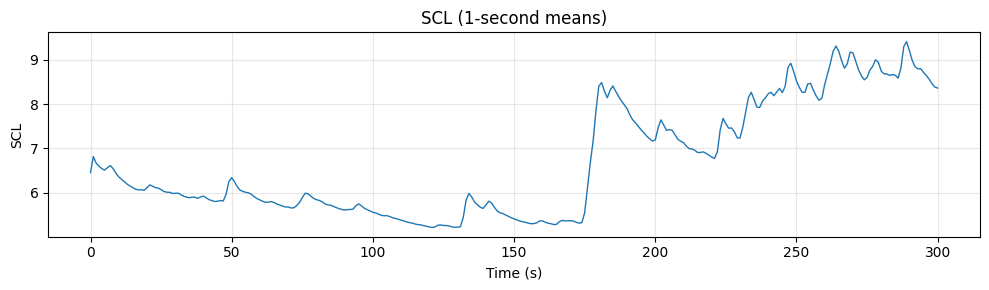

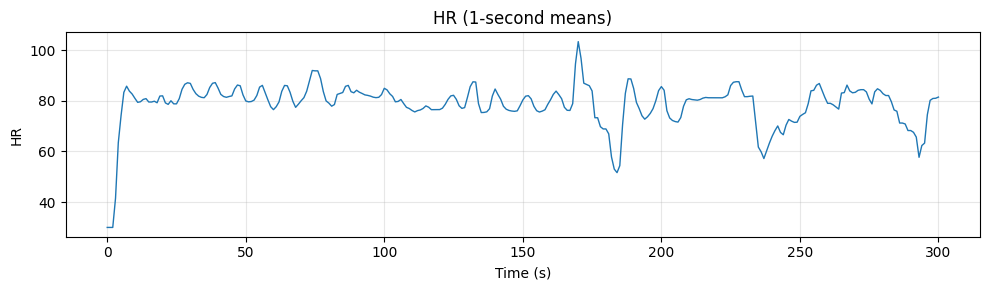

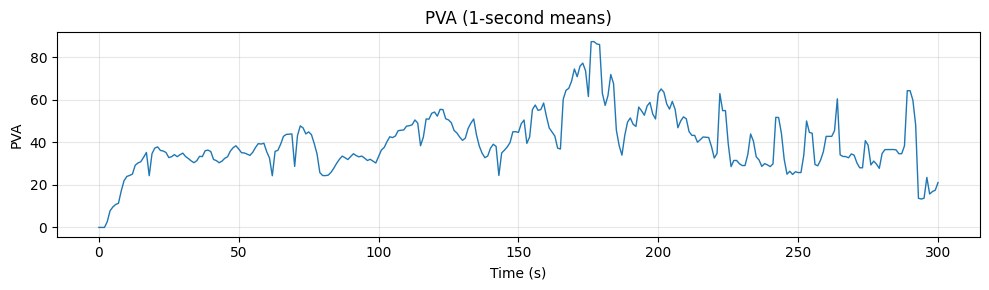

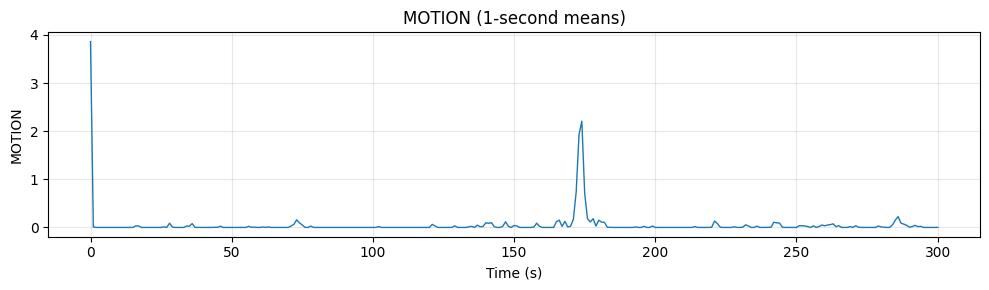

Saved time-series figures: fig_timeseries_SCL.png, fig_timeseries_HR.png, fig_timeseries_PVA.png, fig_timeseries_MOTION.png


In [329]:
# find BVP column name
bvp_col = None
for c in ["U_16_BVP","BVP","bvp"]:
    if c in raw.columns: bvp_col = c; break

# ---------- Time-series plots ----------
signals_wanted = ["SCL","HR","PVA","TEMP","MOTION"]
made = []
for s in signals_wanted:
    if s in down_1s.columns:
        outp = OUT_DIR / f"fig_timeseries_{s}.png"
        ok = plot_signal(down_1s, s, outp)
        if ok: made.append(outp.name)

print("Saved time-series figures:", ", ".join(made) if made else "none found in data")


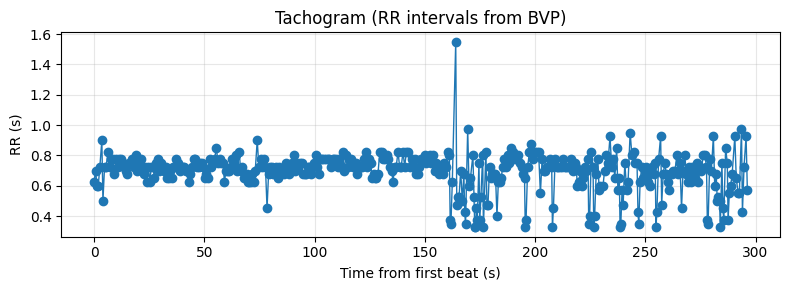

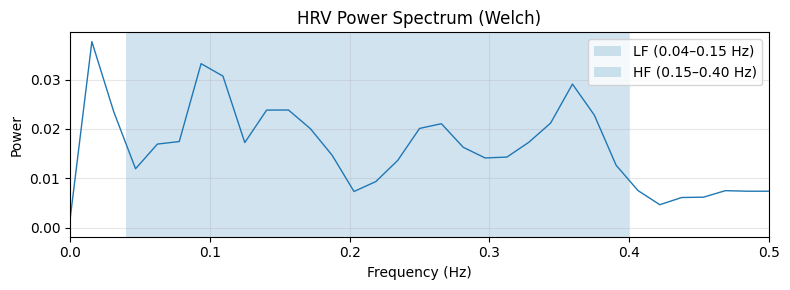

In [330]:
# ---------- HRV: Tachogram + PSD (from BVP) ----------
if bvp_col is not None and "Zeit" in raw.columns:
    t = raw["Zeit"].apply(parse_time_to_seconds)
    x = safe_numeric(raw[bvp_col])
    m = t.notna() & np.isfinite(x)
    t = t[m].to_numpy(); x = x[m]

    if t.size > 10:
        dt = np.median(np.diff(t)); dt = 0.01 if (not np.isfinite(dt) or dt<=0) else dt
        x_d = x - np.nanmean(x)
        min_dist = max(1, int(0.30 / max(dt, 1e-6)))
        prom = 0.3*np.nanstd(x_d) if np.isfinite(np.nanstd(x_d)) else None
        peaks,_ = find_peaks(x_d, distance=min_dist, prominence=prom)

        if peaks.size >= 3:
            t_peaks = t[peaks]
            rr_all  = np.diff(t_peaks)
            ok = (rr_all>=0.30) & (rr_all<=2.00)
            rr   = rr_all[ok]
            t_rr = t_peaks[1:][ok]

            # Tachogram
            if rr.size >= 3:
                fig, ax = plt.subplots(figsize=(8,3))
                ax.plot(t_rr - t_rr.min(), rr, marker='o', lw=1)
                ax.set_title("Tachogram (RR intervals from BVP)")
                ax.set_xlabel("Time from first beat (s)")
                ax.set_ylabel("RR (s)")
                ax.grid(alpha=.3)
                fig.tight_layout()
                fig.savefig(OUT_DIR / "fig_hrv_tachogram.png", dpi=150)
                plt.show()

                # PSD (LF/HF)
                if t_rr.size >= 4:
                    fs = 4.0
                    t_uni = np.arange(t_rr.min(), t_rr.max(), 1.0/fs)
                    if t_uni.size >= 16:
                        f_i  = interp1d(t_rr, rr, kind="linear", bounds_error=False, fill_value="extrapolate")
                        rr_i = f_i(t_uni); rr_i = rr_i - np.mean(rr_i)
                        f, pxx = welch(rr_i, fs=fs, nperseg=min(256, len(rr_i)))

                        fig, ax = plt.subplots(figsize=(8,3))
                        ax.plot(f, pxx, lw=1)
                        ax.axvspan(0.04, 0.15, alpha=.2, label="LF (0.04–0.15 Hz)")
                        ax.axvspan(0.15, 0.40, alpha=.2, label="HF (0.15–0.40 Hz)")
                        ax.set_xlim(0.0, 0.5)
                        ax.set_title("HRV Power Spectrum (Welch)")
                        ax.set_xlabel("Frequency (Hz)")
                        ax.set_ylabel("Power")
                        ax.legend()
                        ax.grid(alpha=.3)
                        fig.tight_layout()
                        fig.savefig(OUT_DIR / "fig_hrv_psd.png", dpi=150)
                        plt.show()
            else:
                print("HRV: too few valid RR intervals for plotting.")
        else:
            print("HRV: no BVP peaks detected (try a calmer segment or check signal quality).")
    else:
        print("HRV: too few BVP samples to analyze.")
else:
    print("No BVP+Zeit columns found for HRV figures; skipping HRV plots.")


In [331]:
# ---------- Show HRV summary + quick interpretations ----------
if hrv_csv.exists():
    hrv = pd.read_csv(hrv_csv)
    print("\nHRV summary (from hrv_summary.csv):")
    display(hrv.T.rename(columns={0:"value"}))

    # quick text cues for report
    if "mean_HR_bpm" in hrv.columns:
        mean_hr = hrv.loc[0, "mean_HR_bpm"]
        print(f"- Mean HR ≈ {mean_hr:.1f} bpm (from RR).")
    if "RMSSD_s" in hrv.columns:
        rmssd_ms = float(hrv.loc[0,"RMSSD_s"]) * 1000.0
        print(f"- RMSSD ≈ {rmssd_ms:.0f} ms (vagal/short-term).")
    if "SDNN_s" in hrv.columns:
        sdnn_ms = float(hrv.loc[0,"SDNN_s"]) * 1000.0
        print(f"- SDNN ≈ {sdnn_ms:.0f} ms (overall variability).")
    if "LF_HF_ratio" in hrv.columns and pd.notna(hrv.loc[0, "LF_HF_ratio"]):
        print(f"- LF/HF ≈ {hrv.loc[0,'LF_HF_ratio']:.2f} (balance index; interpret cautiously).")
else:
    print("hrv_summary.csv not found; run the processing cell first.")


HRV summary (from hrv_summary.csv):


,value
ok,True
n_beats,437
mean_HR_bpm,86.685408
SDNN_s,0.128522
RMSSD_s,0.159824
pNN50_percent,57.683215
LF_power,0.002083
HF_power,0.004051
LF_HF_ratio,0.514328


- Mean HR ≈ 86.7 bpm (from RR).
- RMSSD ≈ 160 ms (vagal/short-term).
- SDNN ≈ 129 ms (overall variability).
- LF/HF ≈ 0.51 (balance index; interpret cautiously).
